The data is about Smartphones , Today I will perform EDA over it to guess the price based on some paramteres

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
smart = pd.read_csv('cleaned_data.csv')
smart.sample(5)

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
623,tecno camon 19 pro,17990,81.0,Android v12,Dual,4g,True,False,False,Helio G96,...,1080x2460,120.0,Punch Hole,"[64, 50, 2]",3,64.0,32.0,1,Dedicated,NaN
292,realme c11 2021,7749,61.0,Android v11,Dual,4g,True,False,False,SC9863A,...,720x1600,NaN,Water Drop Notch,[8],1,8.0,5.0,1,Dedicated,NaN
699,motorola moto edge 30 neo,31990,84.0,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,1080x2400,120.0,Punch Hole,"[64, 13]",2,64.0,32.0,1,Dedicated,NaN
814,cat s22 flip,14999,80.0,NaN,Single,4g,True,False,False,Qualcomm 215,...,480x640,NaN,NaN,[],0,NaN,NaN,1,Dedicated,128.0
441,motorola moto g13,15999,75.0,Android v13,Dual,4g,True,True,False,Helio G85,...,720x1600,90.0,Punch Hole,"[50, 2, 2]",3,50.0,8.0,1,Hybrid,512.0


In [3]:
smart.shape

(968, 27)

In [4]:
smart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model                  968 non-null    object 
 1   price                  968 non-null    int64  
 2   rating                 968 non-null    float64
 3   os                     942 non-null    object 
 4   sim_type               968 non-null    object 
 5   network_type           968 non-null    object 
 6   VoLTE                  968 non-null    bool   
 7   NFC                    968 non-null    bool   
 8   ir_blaster             968 non-null    bool   
 9   chipset                968 non-null    object 
 10  core_type              962 non-null    object 
 11  clock_ghz              927 non-null    float64
 12  ram_gb                 968 non-null    int64  
 13  storage_gb             968 non-null    int64  
 14  battery_mah            957 non-null    float64
 15  fast_c

In [5]:
smart.isna().sum()

model                      0
price                      0
rating                     0
os                        26
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
storage_gb                 0
battery_mah               11
fast_charge_w            204
screen_size_in             1
resolution                 1
refresh_rate_hz          360
display_type              85
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        16
front_camera_mp           25
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       468
dtype: int64

In [6]:
smart.describe()

,price,rating,clock_ghz,ram_gb,storage_gb,battery_mah,fast_charge_w,screen_size_in,refresh_rate_hz,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_max_gb
count,968.000000,968.000000,927.000000,968.000000,968.000000,957.000000,764.00000,967.000000,608.000000,968.000000,952.000000,943.000000,968.0,500.000000
mean,32745.954545,78.540289,2.430237,7.641529,7.641529,4819.935214,46.25877,6.535998,111.656250,2.268595,50.737395,16.714740,1.0,741.136000
std,39707.710721,6.953266,0.464864,23.123619,23.123619,1012.724563,34.30833,0.381498,18.488393,0.905096,33.209502,10.889245,0.0,375.426488
min,2999.000000,60.000000,1.000000,1.000000,1.000000,1500.000000,10.00000,2.400000,90.000000,0.000000,2.000000,2.000000,1.0,32.000000
25%,12999.000000,75.000000,2.050000,4.000000,4.000000,4500.000000,18.00000,6.500000,90.000000,1.000000,48.000000,8.000000,1.0,512.000000
50%,19999.000000,80.000000,2.360000,6.000000,6.000000,5000.000000,33.00000,6.580000,120.000000,3.000000,50.000000,16.000000,1.0,1024.000000
75%,35992.250000,84.000000,2.840000,8.000000,8.000000,5000.000000,66.00000,6.670000,120.000000,3.000000,64.000000,16.000000,1.0,1024.000000
max,650000.000000,89.000000,3.220000,512.000000,512.000000,22000.000000,240.00000,8.030000,240.000000,4.000000,200.000000,60.000000,1.0,2048.000000


In [7]:
for i in list(smart.select_dtypes(include=['object']).columns)[1:]:
    print(i)
    print(smart[i].nunique())




os
35
sim_type
2
network_type
2
chipset
240
core_type
4
resolution
84
display_type
5
rear_camera_mp_list
146
memory_card_type
2


In [8]:
print(smart.loc[smart['ram_gb'] > 32]['ram_gb'])
smart.loc[smart['ram_gb'] > 32]['storage_gb']

397    512
480    512
Name: ram_gb, dtype: int64


397    512
480    512
Name: storage_gb, dtype: int64

In [9]:
smart.loc[smart['ram_gb'] == smart['storage_gb']].shape

(968, 27)

In [10]:
smart.loc[~smart['refresh_rate_hz'].isnull()]['price'].mean()

np.float64(36831.76315789474)

In [11]:
smart.loc[smart['refresh_rate_hz'].isnull()]['price'].mean()

np.float64(25845.477777777778)

In [12]:
smart.loc[smart['refresh_rate_hz'].isnull()]['price'].max()

np.int64(650000)

In [13]:
smart.loc[~smart['refresh_rate_hz'].isnull()]['price'].max()

np.int64(239999)

In [14]:
smart.loc[smart['refresh_rate_hz'].isnull()]['price'].describe()

count       360.000000
mean      25845.477778
std       49639.303128
min        2999.000000
25%        8999.000000
50%       12999.000000
75%       20337.500000
max      650000.000000
Name: price, dtype: float64

In [15]:
smart.loc[~smart['refresh_rate_hz'].isnull()]['price'].describe()

count       608.000000
mean      36831.763158
std       31773.021401
min        7399.000000
25%       16999.000000
50%       24999.000000
75%       42990.000000
max      239999.000000
Name: price, dtype: float64

In [16]:
smart.loc[smart['price'] == 650000]

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
428,vertu signature touch,650000,62.0,Android v4.4.2 (KitKat),Single,4g,False,True,False,Snapdragon 801,...,1080x1920,NaN,NaN,[13],1,13.0,NaN,1,NaN,NaN


In [17]:
import numpy as np
smart.select_dtypes(include=[np.number])

,price,rating,clock_ghz,ram_gb,storage_gb,battery_mah,fast_charge_w,screen_size_in,refresh_rate_hz,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_max_gb
0,54999,89.0,3.20,12,12,5000.0,100.0,6.70,120.0,3,50.0,16.0,1,NaN
1,19989,81.0,2.20,6,6,5000.0,33.0,6.59,120.0,3,64.0,16.0,1,1024.0
2,16499,75.0,2.40,4,4,5000.0,15.0,6.60,90.0,3,50.0,13.0,1,1024.0
3,14999,81.0,2.20,6,6,5000.0,NaN,6.55,120.0,3,50.0,16.0,1,1024.0
4,24999,82.0,2.60,6,6,5000.0,67.0,6.70,120.0,3,108.0,16.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,34990,83.0,3.00,8,8,5000.0,68.2,6.67,120.0,3,64.0,16.0,1,NaN
964,14990,75.0,2.20,6,6,5000.0,22.5,6.50,NaN,2,48.0,8.0,1,1024.0
965,28990,85.0,2.85,8,8,5080.0,67.0,6.60,144.0,3,64.0,16.0,1,NaN
966,19990,80.0,2.20,6,6,5000.0,NaN,6.80,NaN,3,108.0,32.0,1,1024.0


In [18]:
smart['battery_mah'].value_counts()

battery_mah
5000.0    482
4500.0     96
6000.0     60
4000.0     41
4700.0     27
         ... 
3400.0      1
2730.0      1
5180.0      1
8000.0      1
3020.0      1
Name: count, Length: 88, dtype: int64

<Axes: xlabel='battery_mah', ylabel='count'>

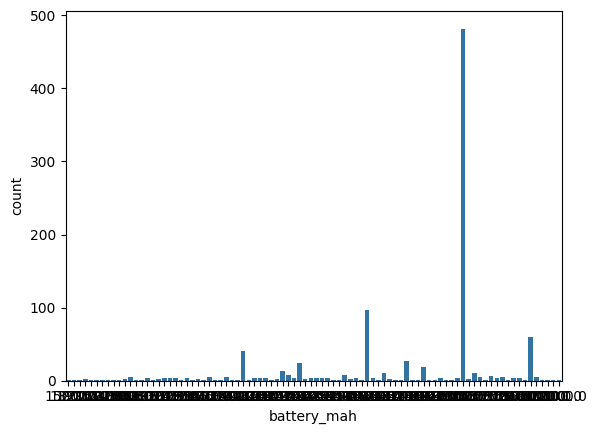

In [19]:
sns.countplot(data = smart, x = 'battery_mah')

In [20]:
smart.drop(columns = ['storage_gb'], axis = 1, inplace = True)
smart

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,1440x3216,120.0,Punch Hole,"[50, 48, 32]",3,50.0,16.0,1,NaN,NaN
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2412,120.0,Punch Hole,"[64, 2, 2]",3,64.0,16.0,1,Hybrid,1024.0
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,1080x2408,90.0,Water Drop Notch,"[50, 2, 2]",3,50.0,13.0,1,Dedicated,1024.0
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2400,120.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,Hybrid,1024.0
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,1080x2412,120.0,Punch Hole,"[108, 8, 2]",3,108.0,16.0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,34990,83.0,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,1080x2460,120.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,Dedicated,NaN
964,honor x8 5g,14990,75.0,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,720x1600,NaN,Water Drop Notch,"[48, 2]",2,48.0,8.0,1,Dedicated,1024.0
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,1080x2460,144.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,NaN,NaN
966,motorola moto g91 5g,19990,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,1080x2400,NaN,Punch Hole,"[108, 8, 2]",3,108.0,32.0,1,Dedicated,1024.0


In [21]:
smart['ram_gb'].value_counts()

ram_gb
8      339
6      230
4      212
12      86
3       51
2       31
16       9
1        6
18       2
512      2
Name: count, dtype: int64

In [22]:
smart['refresh_rate_hz'].value_counts()

refresh_rate_hz
120.0    343
90.0     217
144.0     38
165.0      9
240.0      1
Name: count, dtype: int64

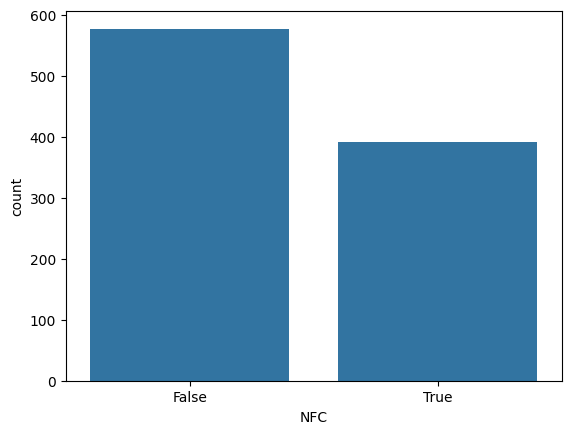

In [23]:
sns.countplot(data = smart, x = 'NFC')
plt.show()

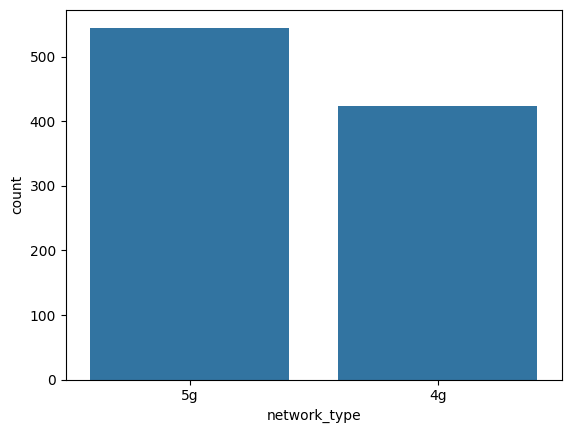

In [24]:
sns.countplot(data = smart, x = 'network_type')
plt.show()

In [25]:
smart.loc[smart['NFC'] == True]['price'].mean()

np.float64(55378.675191815855)

In [26]:
smart.loc[smart['NFC'] == False]['price'].mean()

np.float64(17409.050259965337)

In [27]:
smart.loc[smart['network_type'] == '5g']['price'].mean()

np.float64(43343.26788990826)

In [28]:
smart.loc[smart['network_type'] == '4g']['price'].mean()

np.float64(19092.205673758865)

In [29]:
smart['resolution'].value_counts()

resolution
1080x2400    339
720x1600     146
1080x2408     64
1080x2412     58
1080x2340     43
            ... 
1440x3168      1
1176x2400      1
1560x720       1
2220x1080      1
854x480        1
Name: count, Length: 84, dtype: int64

In [30]:
smart['screen_size_in'].value_counts()

screen_size_in
6.50    116
6.67     95
6.70     93
6.60     91
6.43     43
       ... 
6.09      1
8.00      1
5.20      1
6.75      1
5.86      1
Name: count, Length: 81, dtype: int64

In [31]:
smart.loc[smart['refresh_rate_hz'].isnull(), 'refresh_rate_hz'] = 60

In [32]:
smart.isna().sum()

model                      0
price                      0
rating                     0
os                        26
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
battery_mah               11
fast_charge_w            204
screen_size_in             1
resolution                 1
refresh_rate_hz            0
display_type              85
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        16
front_camera_mp           25
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       468
dtype: int64

In [33]:
smart.drop(index=smart[smart['ram_gb'] == 512].index, inplace=True)

In [34]:
smart['ram_gb'].max()

np.int64(18)

In [35]:
smart.loc[smart['display_type'].isnull()]['price'].mean()

np.float64(76020.7108433735)

In [36]:
smart.loc[~smart['display_type'].isnull()]['price'].mean()

np.float64(28741.185730464327)

In [37]:
smart.loc[smart['display_type'].isnull()]['price'].max()

np.int64(650000)

In [38]:
smart[smart.os.isnull()]

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
69,oppo find n fold,99990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,1792x1920,120.0,Punch Hole,"[64, 10, 8]",3,64.0,32.0,1,Dedicated,NaN
98,vivo x fold 5g,106990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8 Gen1,...,1916x2160,120.0,NaN,[50],1,50.0,16.0,1,Dedicated,NaN
158,oppo find n2 5g,94990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,1792x1920,120.0,Punch Hole,[],0,NaN,NaN,1,NaN,NaN
235,xiaomi mix fold 2 5g,106990,80.0,NaN,Dual,5g,True,True,True,Snapdragon 8+ Gen1,...,1914x2160,120.0,Punch Hole,"[50, 13, 8]",3,50.0,20.0,1,Dedicated,NaN
304,samsung galaxy z flip 3,69999,84.0,NaN,Single,5g,True,True,False,Snapdragon 888,...,1080x2640,120.0,Punch Hole,[],0,NaN,NaN,1,NaN,NaN
319,samsung galaxy z fold 4,154998,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,1812x2176,120.0,Punch Hole,"[50, 12, 10, 10]",4,50.0,10.0,1,Dedicated,NaN
320,royole flexpai 2,109999,87.0,NaN,Dual,5g,True,False,False,Snapdragon 865,...,1440x1920,60.0,NaN,"[64, 16, 8]",3,64.0,32.0,1,Dedicated,NaN
363,oppo find n flip,89990,88.0,NaN,Single,5g,True,True,False,Dimensity 9000,...,1200x2400,120.0,Punch Hole,[],0,NaN,NaN,1,NaN,NaN
389,oppo find n2 flip,70990,88.0,NaN,Single,5g,True,True,False,Dimensity 9000 Plus,...,1080x2520,120.0,Punch Hole,[],0,NaN,NaN,1,NaN,NaN
476,vivo x fold plus,113990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,1916x2160,120.0,Punch Hole,"[50, 16]",2,50.0,16.0,1,Dedicated,NaN


In [39]:
smart['display_type'].fillna('Other', inplace = True)
smart['os'].fillna('Other', inplace = True)
smart.isna().sum()

C:\Users\divya\AppData\Local\Temp\ipykernel_7356\1622924920.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  smart['display_type'].fillna('Other', inplace = True)
C:\Users\divya\AppData\Local\Temp\ipykernel_7356\1622924920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

model                      0
price                      0
rating                     0
os                         0
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
battery_mah               11
fast_charge_w            202
screen_size_in             1
resolution                 1
refresh_rate_hz            0
display_type               0
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        15
front_camera_mp           23
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       467
dtype: int64

In [40]:
smart['battery_mah'].mode()

0    5000.0
Name: battery_mah, dtype: float64

In [41]:
smart.loc[smart['battery_mah'].isnull()]['price'].describe()

count        11.000000
mean      73061.272727
std       37698.178879
min       40999.000000
25%       47994.500000
50%       55999.000000
75%       93949.500000
max      139900.000000
Name: price, dtype: float64

In [42]:
smart.loc[~smart['battery_mah'].isnull()]['price'].describe()

count       955.000000
mean      32339.803141
std       39531.726138
min        3499.000000
25%       12999.000000
50%       19990.000000
75%       34999.000000
max      650000.000000
Name: price, dtype: float64

In [43]:
smart.loc[smart['fast_charge_w'].isnull()]['price'].describe()

count       202.000000
mean      37281.559406
std       61817.109055
min        3499.000000
25%        7999.000000
50%       11999.000000
75%       43674.750000
max      650000.000000
Name: price, dtype: float64

In [44]:
smart.loc[~smart['fast_charge_w'].isnull()]['price'].describe()

count       764.000000
mean      31619.517016
std       31350.153761
min        5785.000000
25%       14999.000000
50%       21990.000000
75%       35096.500000
max      480000.000000
Name: price, dtype: float64

In [45]:
# The Zero-Null Ritual
smart['battery_mah'] = smart['battery_mah'].fillna(0)
smart['fast_charge_w'] = smart['fast_charge_w'].fillna(0)
smart['clock_ghz'] = smart['clock_ghz'].fillna(0)
smart['camera_max_mp'] = smart['rear_camera_max_mp'].fillna(0) # Rename if you prefer
smart['front_camera_mp'] = smart['front_camera_mp'].fillna(0)

# Memory Card Logic: If missing GB, assume no card was specified/supported
smart['memory_card_max_gb'] = smart['memory_card_max_gb'].fillna(0)
smart['memory_card_type'] = smart['memory_card_type'].fillna('None')

# The Final Check
smart.isna().sum()

model                     0
price                     0
rating                    0
os                        0
sim_type                  0
network_type              0
VoLTE                     0
NFC                       0
ir_blaster                0
chipset                   0
core_type                 6
clock_ghz                 0
ram_gb                    0
battery_mah               0
fast_charge_w             0
screen_size_in            1
resolution                1
refresh_rate_hz           0
display_type              0
rear_camera_mp_list       0
rear_camera_count         0
rear_camera_max_mp       15
front_camera_mp           0
memory_card_supported     0
memory_card_type          0
memory_card_max_gb        0
camera_max_mp             0
dtype: int64

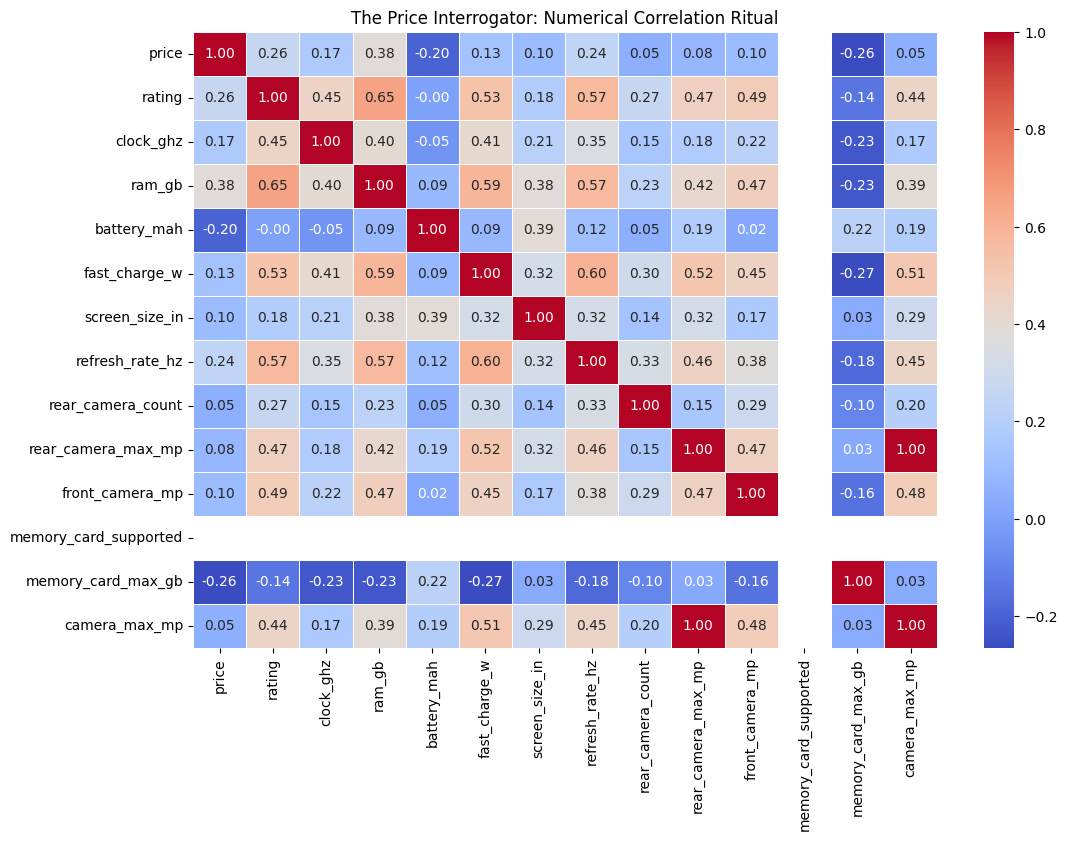

Price Correlation Strengths:
price                    1.000000
ram_gb                   0.383131
rating                   0.264878
refresh_rate_hz          0.239643
clock_ghz                0.171009
fast_charge_w            0.134010
screen_size_in           0.104575
front_camera_mp          0.103071
rear_camera_max_mp       0.084687
rear_camera_count        0.052765
camera_max_mp            0.051864
battery_mah             -0.197171
memory_card_max_gb      -0.261185
memory_card_supported         NaN
Name: price, dtype: float64


In [46]:
numerical_cols = smart.select_dtypes(include=['float64', 'int64']).columns
# 2. Calculate the Correlation Matrix
corr_matrix = smart[numerical_cols].corr()
# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("The Price Interrogator: Numerical Correlation Ritual")
plt.show()
# Extra: Print the correlations specifically with 'price' sorted
print("Price Correlation Strengths:")
print(corr_matrix['price'].sort_values(ascending=False))

In [47]:
smart[smart['battery_mah']==6000].price.mean()

np.float64(22973.433333333334)

In [48]:
smart[smart['battery_mah']==4000].price.mean()

np.float64(35918.60975609756)

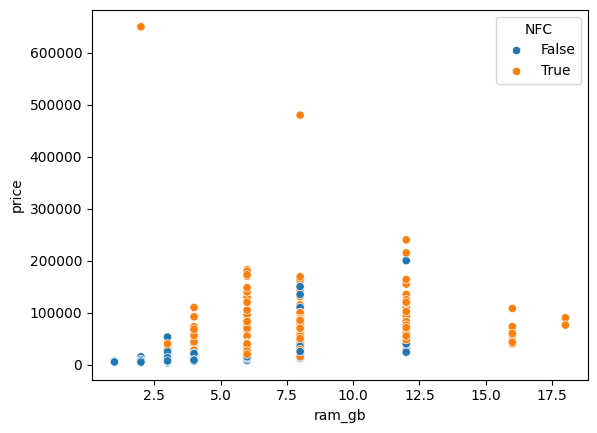

In [49]:
sns.scatterplot(data = smart, x = 'ram_gb', y = 'price', hue = 'NFC')
plt.show()

In [52]:
smart

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,camera_max_mp
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,120.0,Punch Hole,"[50, 48, 32]",3,50.0,16.0,1,None,0.0,50.0
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,120.0,Punch Hole,"[64, 2, 2]",3,64.0,16.0,1,Hybrid,1024.0,64.0
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,90.0,Water Drop Notch,"[50, 2, 2]",3,50.0,13.0,1,Dedicated,1024.0,50.0
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,120.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,Hybrid,1024.0,50.0
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,120.0,Punch Hole,"[108, 8, 2]",3,108.0,16.0,1,None,0.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,34990,83.0,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,120.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,Dedicated,0.0,64.0
964,honor x8 5g,14990,75.0,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,60.0,Water Drop Notch,"[48, 2]",2,48.0,8.0,1,Dedicated,1024.0,48.0
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,144.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,None,0.0,64.0
966,motorola moto g91 5g,19990,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,60.0,Punch Hole,"[108, 8, 2]",3,108.0,32.0,1,Dedicated,1024.0,108.0
